# CDSAXS DeRocher V4: Literal Model4 on Native CPU-Array and Dean GPU

This notebook jumps straight to the literal `Model4` workflow introduced in `CDSAXS_DeRocher_V3.ipynb` and compares the native CPU-array incumbent against the Dean GPU path on the hardest notebook-native trapezoid case.

1. Native CPU-array `differential_evolution` + native `CDSAXS_MCMC`
2. Dean GPU vectorized `differential_evolution` + packaged `CDSAXS_MCMC_GPU`
3. Timing and final-solution comparison
4. Reinvest the saved GPU wall time into a much larger GPU posterior run

This is intentionally **not** a fair budget match. The GPU path is allowed to use a much larger batched DE population and many more MCMC walkers, because that is the point of the notebook.

The geometry path is still the notebook-native one:
`Model1 -> Model2 = Model1.add_layer_at_percentage(10) -> Model4 = Model2.add_layer_at_percentage(10)`.

The crucial Notebook 3 detail is that literal `Model4` is grown from a **fitted** `Model2`, not from the raw base defaults. This notebook now loads that fitted `Model2` seed from a saved artifact in the same directory instead of recomputing it every run, then compares the CPU and GPU `Model4` workflows from the same starting basin.


In [1]:
from __future__ import annotations

import contextlib
import copy
import io
import sys
import time
import warnings
from pathlib import Path

import corner
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.random.seed(1234)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 1234


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "cdsaxs").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing src/cdsaxs")


REPO_ROOT = find_repo_root()
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from cdsaxs.Fitting.Trapezoid_model import TrapezoidModelArray as TMCPU
from cdsaxs.Fitting.Trapezoid_model_dean_gpu import TrapezoidModelArrayDeanGPUFused as TMGPU


## Notebook Helpers

The notebook-local helpers do five things:
- load the shared fitted `Model2` seed artifact so literal `Model4` matches Notebook 3
- keep the inherited `Model2` bootstrap out of the timed CPU vs GPU comparison
- make wall-clock timing explicit in the notebook itself with simple in-cell start/stop timing
- recenter both MCMC workflows on the DE optimum before sampling
- sample only a curated structural posterior subset while holding the DE-optimized per-cut backgrounds fixed


In [2]:
DATA_PATH = REPO_ROOT / "examples" / "fitting_examples" / "75s_30nm_200nmpitch_IvsQz.csv"
MODEL2_SEED_ARTIFACT = REPO_ROOT / "examples" / "fitting_examples" / "CDSAXS_DeRocher_V4_Model2_seed.pkl"

BASE_MODEL_PARAMS = {
    "layers": 1,
    "trapezoids": [
        {"width": 400.0, "height": 700.0},
        {"width": 83.0, "height": 0.0},
    ],
    "DW": 15.0,
    "I0": 0.000001,
    "Bk": 0.5,
    "slds": [1.0],
    "optimization": {
        "trap_0_width": {"min": 300.0, "max": 1200.0, "default": 400.0},
        "trap_0_height": {"min": 500.0, "max": 800.0, "default": 700.0},
        "trap_1_width": {"min": 10.0, "max": 120.0, "default": 83.0},
        "DW": {"min": 1.0, "max": 50.0, "default": 15.0},
    },
}

SEED_BOOTSTRAP_DE_KWARGS = {
    "maxiter": 60,
    "popsize": 32,
    "tol": 0.05,
    "atol": 0.0,
    "init": "sobol",
    "mutation": 1.0,
    "recombination": 0.5,
    "polish": False,
    "seed": SEED,
}

CPU_DE_KWARGS = {
    "maxiter": 50,
    "popsize": 16,
    "tol": 0.0,
    "atol": 0.0,
    "init": "sobol",
    "mutation": 1.0,
    "recombination": 0.5,
    "polish": False,
    "seed": SEED,
}

GPU_DE_KWARGS = {
    "maxiter": 50,
    "popsize": 16,
    "tol": 0.0,
    "atol": 0.0,
    "init": "sobol",
    "mutation": 1.0,
    "recombination": 0.5,
    "polish": False,
    "seed": SEED,
}

CPU_MCMC_KWARGS = {
    "n_walkers": 64,
    "n_steps": 200,
    "burn_in": 50,
    "thin": 1,
    "seed": SEED,
}

GPU_MCMC_KWARGS = {
    "n_walkers": 64,
    "n_steps": 200,
    "burn_in": 50,
    "thin": 1,
    "seed": SEED,
}

GPU_STRETCH_MCMC_KWARGS = {
    "n_walkers": 2048,
    "n_steps": 1000,
    "burn_in": 200,
    "thin": 1,
    "seed": SEED,
}

SELECTED_CUTS = [0, 5, 10, 15]
PARAMETER_SUBSET = [
    "trap_0_width",
    "trap_0_height",
    "trap_1_width",
    "trap_1_height",
    "trap_2_width",
    "trap_2_height",
    "trap_3_width",
    "DW",
]

PALETTE = {
    "cpu": "#264653",
    "gpu": "#E76F51",
    "stretch": "#2A9D8F",
    "measured": "#7A7A7A",
}

MODEL2_SEED_CONTEXT = None


def build_base_model(model_cls, freeform_use_cupy: bool = False):
    model = model_cls(
        model="single_material",
        layers=1,
        model_params=copy.deepcopy(BASE_MODEL_PARAMS),
    )
    model._freeform_use_cupy = bool(freeform_use_cupy)
    model.importCDSAXS_GUI(str(DATA_PATH))
    return model


def load_model2_seed_context():
    import pickle

    if not MODEL2_SEED_ARTIFACT.exists():
        raise FileNotFoundError(
            f"Missing {MODEL2_SEED_ARTIFACT.name}. Regenerate the saved Model2 seed artifact before running this notebook."
        )

    with MODEL2_SEED_ARTIFACT.open("rb") as handle:
        return pickle.load(handle)


def get_model2_seed_context():
    global MODEL2_SEED_CONTEXT
    if MODEL2_SEED_CONTEXT is None:
        MODEL2_SEED_CONTEXT = load_model2_seed_context()
    return MODEL2_SEED_CONTEXT


def build_seeded_model4_cpu():
    seed_context = get_model2_seed_context()
    model2 = copy.deepcopy(seed_context["model2"])
    model4 = model2.add_layer_at_percentage(10)
    model4._freeform_use_cupy = False
    model4.model_params["slds"] = [1, 1, 1]
    model4.model_params["Bk"] = 0.5
    model4.SimInt = model4.simulate_structure()
    model4.GF = model4.GF_calc(model4.SimInt)
    model4.BIC = model4.BIC_calc(model4.GF)
    return model4


def build_seeded_model4_gpu():
    seed_context = get_model2_seed_context()
    model2_params = copy.deepcopy(seed_context["params"])

    model2 = TMGPU(
        model="single_material",
        layers=2,
        model_params=copy.deepcopy(model2_params),
    )
    model2._freeform_use_cupy = True
    model2.importCDSAXS_GUI(str(DATA_PATH))
    model2.model_params = copy.deepcopy(model2_params)
    model2.update_traditional_from_model_params()

    model4 = model2.add_layer_at_percentage(10)
    model4._freeform_use_cupy = True
    model4.model_params["slds"] = [1, 1, 1]
    model4.model_params["Bk"] = 0.5
    model4.SimInt = model4.simulate_structure()
    model4.GF = model4.GF_calc(model4.SimInt)
    model4.BIC = model4.BIC_calc(model4.GF)
    return model4


def describe_model4(model) -> pd.DataFrame:
    param_names = list(model.model_params["optimization"].keys())
    return pd.DataFrame(
        [
            {
                "layers": int(model.layers),
                "trapezoids": int(len(model.model_params["trapezoids"])),
                "optimization_params": int(len(param_names)),
                "background_terms": int(sum(name.startswith("Bk_") for name in param_names)),
                "first_param": param_names[0],
                "last_param": param_names[-1],
                "initial_GF": float(model.GF),
                "initial_BIC": float(model.BIC),
            }
        ]
    )


def params_centered_on_current_solution(model) -> dict:
    params = copy.deepcopy(model.model_params["optimization"])
    values = None
    if getattr(model, "optimization_result", None) is not None and hasattr(model.optimization_result, "x"):
        values = np.asarray(model.optimization_result.x, dtype=float)
    if values is None:
        param_names = list(params.keys())
        values = np.asarray([params[name]["default"] for name in param_names], dtype=float)

    param_names = list(getattr(model, "param_names", params.keys()))
    for name, value in zip(param_names, values):
        if name in params:
            params[name] = dict(params[name])
            params[name]["default"] = float(value)
    return params


def select_mcmc_params(model, keep_names=PARAMETER_SUBSET) -> dict:
    params = params_centered_on_current_solution(model)
    selected = {name: copy.deepcopy(params[name]) for name in keep_names if name in params}
    if not selected:
        raise ValueError("No requested MCMC parameters were found in the model optimization dictionary")
    return selected


def realized_de_population(model, de_kwargs: dict) -> int:
    n_params = len(model.model_params["optimization"])
    raw_population = int(de_kwargs["popsize"]) * n_params
    if str(de_kwargs.get("init", "")).lower() == "sobol":
        return int(2 ** np.ceil(np.log2(max(raw_population, 1))))
    return int(raw_population)


def describe_workflow_budget(workflow: str, model, de_kwargs: dict, mcmc_kwargs: dict, mcmc_param_names) -> pd.DataFrame:
    population = realized_de_population(model, de_kwargs)
    maxiter = int(de_kwargs["maxiter"])
    n_walkers = int(mcmc_kwargs["n_walkers"])
    n_steps = int(mcmc_kwargs["n_steps"])
    burn_in = int(mcmc_kwargs.get("burn_in", 0))

    return pd.DataFrame(
        [
            {
                "workflow": workflow,
                "DE popsize arg": int(de_kwargs["popsize"]),
                "DE realized candidates/gen": int(population),
                "Approx DE objective calls": int(population * (maxiter + 1)),
                "MCMC sampled params": int(len(list(mcmc_param_names))),
                "MCMC walkers": n_walkers,
                "MCMC steps": n_steps,
                "Burn-in": burn_in,
                "Posterior samples after burn-in": int(max(n_steps - burn_in, 0) * n_walkers),
            }
        ]
    )


def build_workflow_summary(label: str, model, mcmc_results: dict, timing_rows: list[dict], gf_after_de: float, sampled_param_names) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "workflow": label,
                "MCMC sampled params": int(len(list(sampled_param_names))),
                "GF after DE": float(gf_after_de),
                "GF final": float(model.GF),
                "BIC final": float(model.BIC),
                "best_log_prob": float(mcmc_results["best_log_prob"]),
                "mean_acceptance": float(mcmc_results["mean_acceptance"]),
                "effective_samples": int(mcmc_results["effective_samples"]),
                "total_seconds": float(sum(row["elapsed_seconds"] for row in timing_rows)),
            }
        ]
    )


def build_timing_comparison(cpu_rows: list[dict], gpu_rows: list[dict]) -> pd.DataFrame:
    cpu_df = pd.DataFrame(cpu_rows).set_index("stage")
    gpu_df = pd.DataFrame(gpu_rows).set_index("stage")
    rows = []

    for stage in ["DE", "MCMC"]:
        rows.append(
            {
                "stage": stage,
                "CPU seconds": float(cpu_df.loc[stage, "elapsed_seconds"]),
                "GPU seconds": float(gpu_df.loc[stage, "elapsed_seconds"]),
            }
        )

    rows.append(
        {
            "stage": "Total",
            "CPU seconds": float(cpu_df["elapsed_seconds"].sum()),
            "GPU seconds": float(gpu_df["elapsed_seconds"].sum()),
        }
    )

    comparison = pd.DataFrame(rows)
    comparison["Speedup (CPU/GPU)"] = comparison["CPU seconds"] / comparison["GPU seconds"]
    return comparison


def plot_timing_comparison(comparison_df: pd.DataFrame) -> None:
    x = np.arange(len(comparison_df))
    width = 0.34

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, comparison_df["CPU seconds"], width, color=PALETTE["cpu"], label="Native CPU-array")
    ax.bar(x + width / 2, comparison_df["GPU seconds"], width, color=PALETTE["gpu"], label="Dean GPU vectorized")

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df["stage"])
    ax.set_ylabel("Wall time (s, log scale)")
    ax.set_title("Literal Model4 timing from the saved fitted Model2 seed")
    ax.legend()

    for idx, row in comparison_df.iterrows():
        y = max(row["CPU seconds"], row["GPU seconds"]) * 1.18
        ax.text(idx, y, f"{row['Speedup (CPU/GPU)']:.1f}x", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


def _trapezoid_polygon(model):
    trapezoids = model.model_params["trapezoids"]
    widths = [float(trapezoids[0]["width"])]
    heights = [0.0]
    running_height = 0.0

    for idx in range(len(trapezoids) - 1):
        running_height += float(trapezoids[idx]["height"])
        heights.append(running_height)
        widths.append(float(trapezoids[idx + 1]["width"]))

    left = [-0.5 * width for width in widths]
    right = [0.5 * width for width in widths]
    x = np.array(left + right[::-1] + [left[0]], dtype=float)
    y = np.array(heights + heights[::-1] + [heights[0]], dtype=float)
    return x, y


def plot_structure_overlay(models, labels, colors, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    for model, label, color in zip(models, labels, colors):
        x, y = _trapezoid_polygon(model)
        ax.plot(
            x,
            y,
            color=color,
            linewidth=2.5,
            alpha=0.7,
            label=f"{label} (GF={model.GF:.1f})",
        )
        ax.fill(x, y, color=color, alpha=0.035)

    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Lateral position (A)")
    ax.set_ylabel("Height (A)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def plot_fit_overlay(models, labels, colors, cuts=SELECTED_CUTS, title: str = "") -> None:
    reference = models[0]
    n_cuts = len(cuts)
    n_cols = 2
    n_rows = int(np.ceil(n_cuts / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, cut in zip(axes, cuts):
        qz = reference.Qz[:, cut]
        qx = reference.Qx[0, cut]
        ax.semilogy(
            qz,
            reference.Intensity[:, cut],
            "o",
            color=PALETTE["measured"],
            markersize=3,
            alpha=0.8,
            label="Measured",
        )

        for model, label, color in zip(models, labels, colors):
            ax.semilogy(
                qz,
                model.SimInt[:, cut],
                "-",
                color=color,
                linewidth=2.0,
                alpha=0.72,
                label=f"{label} (GF={model.GF:.1f})",
            )

        ax.set_title(f"Cut {cut} | Qx = {qx:.4f}")
        ax.set_xlabel("Qz (A^-1)")
        ax.set_ylabel("Intensity (a.u.)")

    for ax in axes[n_cuts:]:
        ax.axis("off")

    handles, legend_labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(3, len(unique)),
        frameon=False,
    )
    fig.suptitle(title, y=1.07)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def subset_flat_chains(mcmc_results: dict, keep_names: list[str], max_samples: int = 4000):
    param_names = list(mcmc_results["param_names"])
    indices = [param_names.index(name) for name in keep_names]
    subset = np.asarray(mcmc_results["flat_chains"][:, indices], dtype=float)
    if subset.shape[0] > max_samples:
        sample_idx = np.linspace(0, subset.shape[0] - 1, max_samples, dtype=int)
        subset = subset[sample_idx]
    return subset


def plot_corner_subset(mcmc_results: dict, keep_names: list[str], title: str, color: str) -> None:
    subset = subset_flat_chains(mcmc_results, keep_names)
    fig = corner.corner(
        subset,
        labels=keep_names,
        show_titles=True,
        title_fmt=".2f",
        title_kwargs={"fontsize": 10},
        color=color,
        plot_density=True,
        plot_contours=True,
        fill_contours=True,
        levels=(0.68, 0.95),
        smooth=1.0,
    )
    fig.suptitle(title, y=1.02)
    plt.show()


## Literal Model4

`Model4` remains the hardest notebook-native structure in `CDSAXS_DeRocher_V3.ipynb`: one added layer at 10%, then a second added layer at 10% again.

The key Notebook 3 lesson is numerical rather than cosmetic: the literal `Model4` comparison only makes sense when it inherits a **fitted** `Model2` seed. That seed is now loaded from a saved artifact in this directory, so the notebook starts from the right basin immediately instead of paying the bootstrap cost every run.


Loaded Model2 seed artifact: CDSAXS_DeRocher_V4_Model2_seed.pkl


,seed stage,model,optimizer,elapsed_seconds,GF
0,Inherited seed,Model1,CPU-array differential_evolution,2.8890,1217.4032
1,Inherited seed,Model2,CPU-array differential_evolution,65.1058,1092.2561


,layers,trapezoids,optimization_params,background_terms,first_param,last_param,initial_GF,initial_BIC
0,3,4,29,20,trap_0_width,Bk_19,1395.8114,1452.5807


<Axes: title={'center': 'Literal Model4 geometry from the saved fitted Model2 seed'}, xlabel='Width (Å)', ylabel='Height (Å)'>

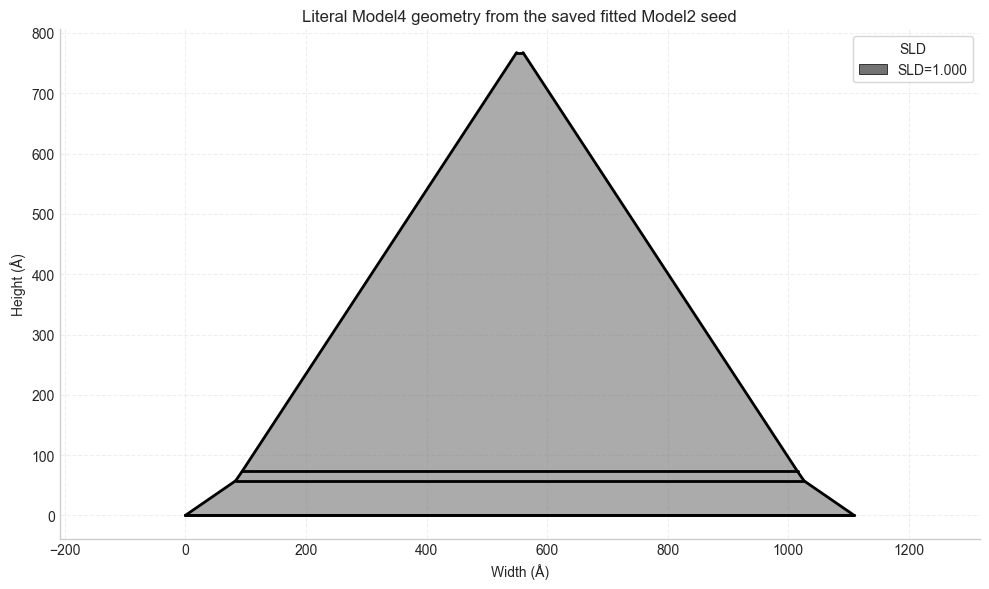

In [3]:
seed_context = get_model2_seed_context()
print(f"Loaded Model2 seed artifact: {MODEL2_SEED_ARTIFACT.name}")
seed_bootstrap_df = pd.DataFrame(seed_context["bootstrap_rows"])
display(seed_bootstrap_df.round(4))

model4_preview = build_seeded_model4_cpu()
display(describe_model4(model4_preview).round(4))
model4_preview.plot_structure(
    title="Literal Model4 geometry from the saved fitted Model2 seed",
    show_vacuum_region=False,
    shade_by_sld=True,
    color="black",
)


## Section 1: Native CPU-Array DE + Native MCMC

The timing wrapper is visible in the code below. DE still optimizes the full literal `Model4` parameter set, but the native MCMC samples only the curated structural subset after recentering on the DE optimum. That keeps the API close to Notebook 3 while freezing the DE-optimized per-cut backgrounds instead of trying to sample all 20 of them in the posterior.


In [4]:
cpu_model = build_seeded_model4_cpu()
cpu_timing_rows = []

display(describe_workflow_budget("Native CPU-array", cpu_model, CPU_DE_KWARGS, CPU_MCMC_KWARGS, PARAMETER_SUBSET))

cpu_de_start = time.perf_counter()
cpu_de_result = cpu_model.CDSAXS_Optimize(
    optimizer="differential_evolution",
    use_callbacks=False,
    verbose=False,
    vectorized=True,
    freeform_use_cupy=False,
    plot_results=False,
    plot_structure=False,
    plot_grid=False,
    plot_combined=False,
    **CPU_DE_KWARGS,
)
cpu_de_elapsed = time.perf_counter() - cpu_de_start
print(f"CPU native-array differential_evolution: {cpu_de_elapsed:.3f} s")
cpu_timing_rows.append(
    {
        "stage": "DE",
        "label": "CPU native-array differential_evolution",
        "elapsed_seconds": float(cpu_de_elapsed),
    }
)
cpu_gf_after_de = float(cpu_model.GF)

cpu_sampling_params = select_mcmc_params(cpu_model)
cpu_corner_param_names = list(cpu_sampling_params.keys())
cpu_mcmc_start = time.perf_counter()
cpu_mcmc_result = cpu_model.CDSAXS_MCMC(
    params_to_sample=cpu_sampling_params,
    progress=False,
    plot_results=False,
    verbose=False,
    **CPU_MCMC_KWARGS,
)
cpu_mcmc_elapsed = time.perf_counter() - cpu_mcmc_start
print(f"CPU native MCMC: {cpu_mcmc_elapsed:.3f} s")
cpu_timing_rows.append(
    {
        "stage": "MCMC",
        "label": "CPU native MCMC",
        "elapsed_seconds": float(cpu_mcmc_elapsed),
    }
)

cpu_timing_table = pd.DataFrame(cpu_timing_rows)
cpu_summary = build_workflow_summary(
    "Native CPU-array",
    cpu_model,
    cpu_mcmc_result,
    cpu_timing_rows,
    gf_after_de=cpu_gf_after_de,
    sampled_param_names=cpu_corner_param_names,
)

display(cpu_timing_table.round(3))
display(cpu_summary.round(4))


,workflow,DE popsize arg,DE realized candidates/gen,Approx DE objective calls,MCMC sampled params,MCMC walkers,MCMC steps,Burn-in,Posterior samples after burn-in
0,Native CPU-array,16,512,26112,8,64,200,50,9600


/home/deand/mambaforge/envs/cdsaxs_dev/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


CPU native-array differential_evolution: 47.518 s


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 4;
tau: [21.84538241 17.38128836 18.20179558 21.32392542 18.85332792 17.89171523
 19.83821697 16.54842401]


CPU native MCMC: 19.732 s


,stage,label,elapsed_seconds
0,DE,CPU native-array differential_evolution,47.518
1,MCMC,CPU native MCMC,19.732


,workflow,MCMC sampled params,GF after DE,GF final,BIC final,best_log_prob,mean_acceptance,effective_samples,total_seconds
0,Native CPU-array,8,1092.5357,1070.0124,1127.9416,-535.0062,0.4092,9600,67.2503


## Section 2: Dean GPU DE + Packaged Vectorized MCMC

This section stays parallel to Section 1. The workflow differences are the Dean GPU model class, vectorized DE evaluation on the GPU, a much larger batched DE population, and the packaged `CDSAXS_MCMC_GPU(...)` call. The same curated structural posterior subset is sampled here too, so the comparison stays focused on compute capability instead of on whether 20 background terms are easy to sample.


In [5]:
gpu_model = build_seeded_model4_gpu()
gpu_timing_rows = []

display(describe_workflow_budget("Dean GPU vectorized", gpu_model, GPU_DE_KWARGS, GPU_MCMC_KWARGS, PARAMETER_SUBSET))

gpu_de_start = time.perf_counter()
gpu_de_result = gpu_model.CDSAXS_Optimize(
    optimizer="differential_evolution",
    use_callbacks=False,
    verbose=False,
    vectorized=True,
    freeform_use_cupy=True,
    plot_results=False,
    plot_structure=False,
    plot_grid=False,
    plot_combined=False,
    **GPU_DE_KWARGS,
)
gpu_de_elapsed = time.perf_counter() - gpu_de_start
print(f"Dean GPU differential_evolution: {gpu_de_elapsed:.3f} s")
gpu_timing_rows.append(
    {
        "stage": "DE",
        "label": "Dean GPU differential_evolution",
        "elapsed_seconds": float(gpu_de_elapsed),
    }
)
gpu_gf_after_de = float(gpu_model.GF)

gpu_sampling_params = select_mcmc_params(gpu_model)
gpu_corner_param_names = list(gpu_sampling_params.keys())
gpu_mcmc_start = time.perf_counter()
gpu_mcmc_result = gpu_model.CDSAXS_MCMC_GPU(
    params_to_sample=gpu_sampling_params,
    progress=False,
    plot_results=False,
    verbose=False,
    **GPU_MCMC_KWARGS,
)
gpu_mcmc_elapsed = time.perf_counter() - gpu_mcmc_start
print(f"Dean GPU vectorized MCMC: {gpu_mcmc_elapsed:.3f} s")
gpu_timing_rows.append(
    {
        "stage": "MCMC",
        "label": "Dean GPU vectorized MCMC",
        "elapsed_seconds": float(gpu_mcmc_elapsed),
    }
)

gpu_timing_table = pd.DataFrame(gpu_timing_rows)
gpu_summary = build_workflow_summary(
    "Dean GPU vectorized",
    gpu_model,
    gpu_mcmc_result,
    gpu_timing_rows,
    gf_after_de=gpu_gf_after_de,
    sampled_param_names=gpu_corner_param_names,
)

display(gpu_timing_table.round(3))
display(gpu_summary.round(4))


,workflow,DE popsize arg,DE realized candidates/gen,Approx DE objective calls,MCMC sampled params,MCMC walkers,MCMC steps,Burn-in,Posterior samples after burn-in
0,Dean GPU vectorized,16,512,26112,8,64,200,50,9600


/home/deand/mambaforge/envs/cdsaxs_dev/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


Dean GPU differential_evolution: 0.809 s


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 4;
tau: [21.84538241 17.38128836 18.20179558 21.32392542 18.85332792 17.89171523
 19.83821697 16.54842401]


Dean GPU vectorized MCMC: 1.002 s


,stage,label,elapsed_seconds
0,DE,Dean GPU differential_evolution,0.809
1,MCMC,Dean GPU vectorized MCMC,1.002


,workflow,MCMC sampled params,GF after DE,GF final,BIC final,best_log_prob,mean_acceptance,effective_samples,total_seconds
0,Dean GPU vectorized,8,1092.5357,1070.0124,1127.9416,-535.0062,0.4092,9600,1.8108


## Section 3: Timing and Final-Solution Comparison

The point here is not fairness. The GPU path is allowed to spend a much larger DE population and many more walkers, because the hardware can support it. The useful comparison is whether that more aggressive workflow still finishes faster while landing on an equal-or-better literal `Model4` fit from the same inherited `Model2` seed.


,workflow,DE popsize arg,DE realized candidates/gen,Approx DE objective calls,MCMC sampled params,MCMC walkers,MCMC steps,Burn-in,Posterior samples after burn-in
0,Native CPU-array,16,512,26112,8,64,200,50,9600
1,Dean GPU vectorized,16,512,26112,8,64,200,50,9600


,workflow,MCMC sampled params,GF after DE,GF final,BIC final,best_log_prob,mean_acceptance,effective_samples,total_seconds
0,Native CPU-array,8,1092.5357,1070.0124,1127.9416,-535.0062,0.4092,9600,67.2503
1,Dean GPU vectorized,8,1092.5357,1070.0124,1127.9416,-535.0062,0.4092,9600,1.8108


,stage,CPU seconds,GPU seconds,Speedup (CPU/GPU)
0,DE,47.518,0.809,58.753
1,MCMC,19.732,1.002,19.693
2,Total,67.250,1.811,37.139


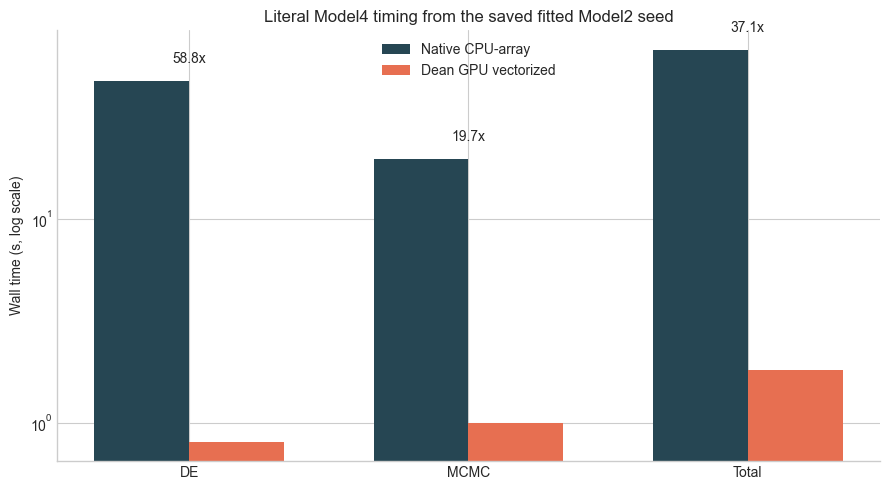

In [6]:
workflow_budget_df = pd.concat(
    [
        describe_workflow_budget("Native CPU-array", cpu_model, CPU_DE_KWARGS, CPU_MCMC_KWARGS, cpu_corner_param_names),
        describe_workflow_budget("Dean GPU vectorized", gpu_model, GPU_DE_KWARGS, GPU_MCMC_KWARGS, gpu_corner_param_names),
    ],
    ignore_index=True,
)
workflow_summary_df = pd.concat([cpu_summary, gpu_summary], ignore_index=True)
comparison_df = build_timing_comparison(cpu_timing_rows, gpu_timing_rows)

display(workflow_budget_df)
display(workflow_summary_df.round(4))
display(comparison_df.round(3))
plot_timing_comparison(comparison_df)


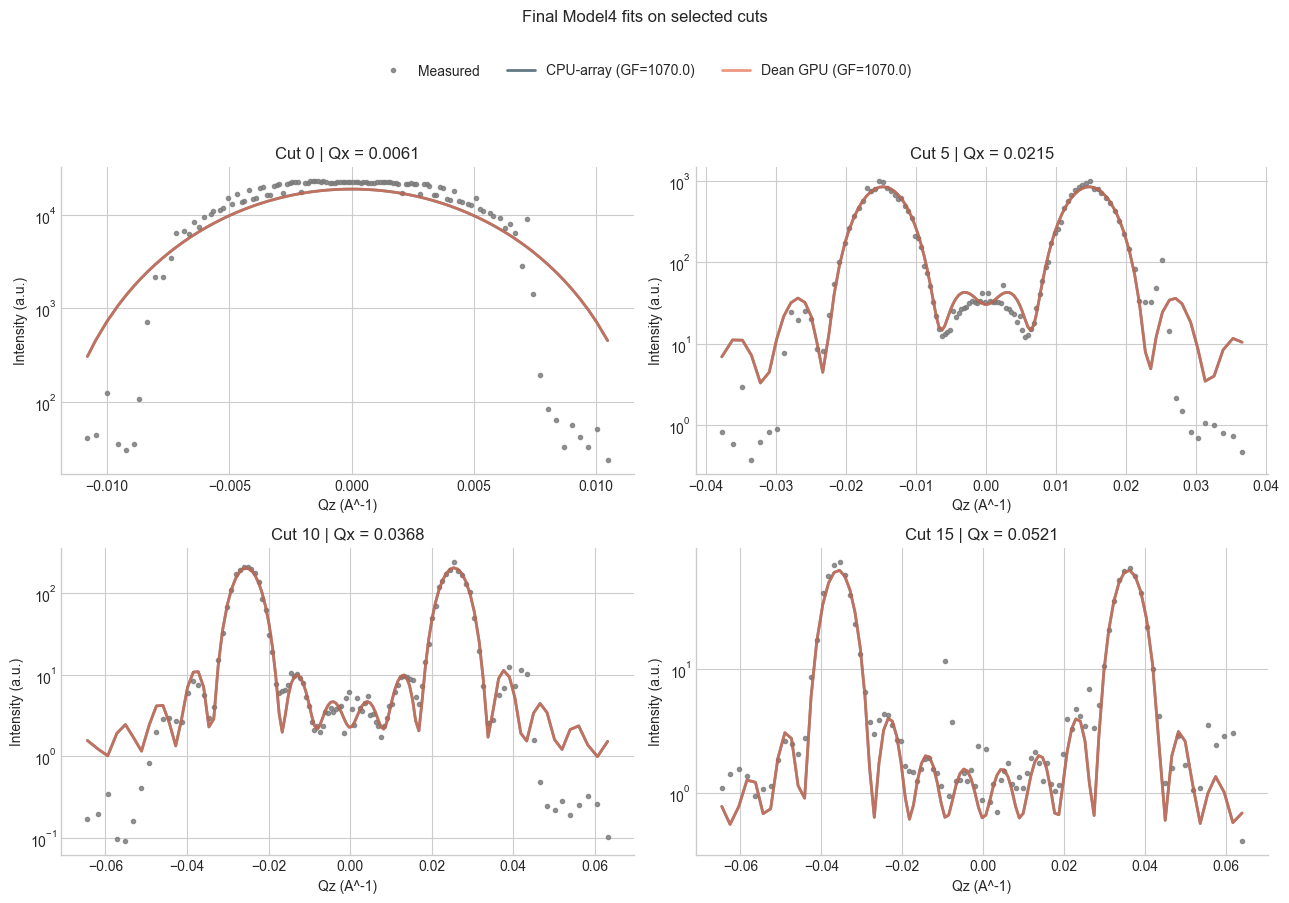

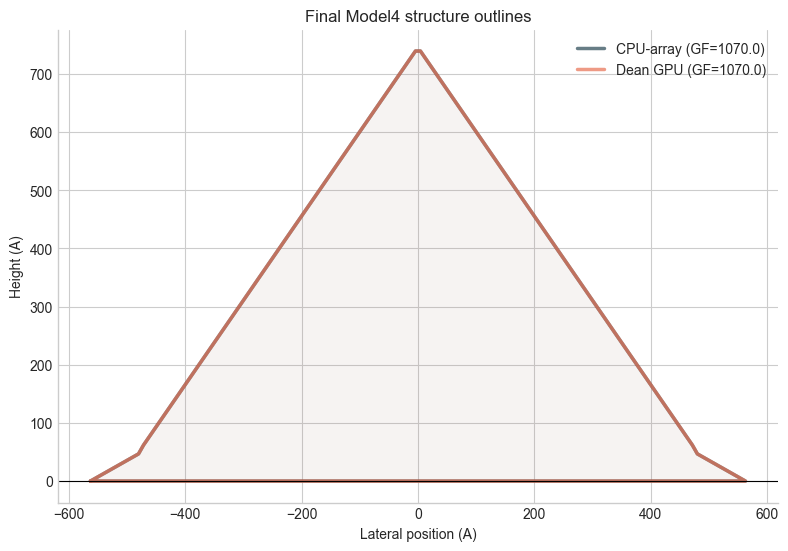

In [7]:
plot_fit_overlay(
    [cpu_model, gpu_model],
    ["CPU-array", "Dean GPU"],
    [PALETTE["cpu"], PALETTE["gpu"]],
    cuts=SELECTED_CUTS,
    title="Final Model4 fits on selected cuts",
)

plot_structure_overlay(
    [cpu_model, gpu_model],
    ["CPU-array", "Dean GPU"],
    [PALETTE["cpu"], PALETTE["gpu"]],
    title="Final Model4 structure outlines",
)


## Section 4: Reinvest the GPU Savings Into More Posterior Work

Here the DE seed is kept fixed and the GPU savings are spent on a much larger vectorized posterior run over the same curated structural subset. This is the cleanest way to show what the GPU buys: more walkers, many more post-burn samples, and tighter posteriors on the same literal `Model4` problem.


In [8]:
gpu_stretch_model = build_seeded_model4_gpu()
gpu_stretch_timing_rows = []

display(describe_workflow_budget("Dean GPU stretch", gpu_stretch_model, GPU_DE_KWARGS, GPU_STRETCH_MCMC_KWARGS, PARAMETER_SUBSET))

gpu_stretch_de_start = time.perf_counter()
gpu_stretch_de_result = gpu_stretch_model.CDSAXS_Optimize(
    optimizer="differential_evolution",
    use_callbacks=False,
    verbose=False,
    vectorized=True,
    freeform_use_cupy=True,
    plot_results=False,
    plot_structure=False,
    plot_grid=False,
    plot_combined=False,
    **GPU_DE_KWARGS,
)
gpu_stretch_de_elapsed = time.perf_counter() - gpu_stretch_de_start
print(f"Dean GPU differential_evolution (same DE seed): {gpu_stretch_de_elapsed:.3f} s")
gpu_stretch_timing_rows.append(
    {
        "stage": "DE",
        "label": "Dean GPU differential_evolution (same DE seed)",
        "elapsed_seconds": float(gpu_stretch_de_elapsed),
    }
)
gpu_stretch_gf_after_de = float(gpu_stretch_model.GF)

gpu_stretch_sampling_params = select_mcmc_params(gpu_stretch_model)
gpu_stretch_corner_param_names = list(gpu_stretch_sampling_params.keys())
gpu_stretch_mcmc_start = time.perf_counter()
gpu_stretch_mcmc_result = gpu_stretch_model.CDSAXS_MCMC_GPU(
    params_to_sample=gpu_stretch_sampling_params,
    progress=False,
    plot_results=False,
    verbose=False,
    **GPU_STRETCH_MCMC_KWARGS,
)
gpu_stretch_mcmc_elapsed = time.perf_counter() - gpu_stretch_mcmc_start
print(f"Dean GPU stretch MCMC: {gpu_stretch_mcmc_elapsed:.3f} s")
gpu_stretch_timing_rows.append(
    {
        "stage": "MCMC",
        "label": "Dean GPU stretch MCMC",
        "elapsed_seconds": float(gpu_stretch_mcmc_elapsed),
    }
)

gpu_stretch_timing_table = pd.DataFrame(gpu_stretch_timing_rows)
gpu_stretch_summary = build_workflow_summary(
    "Dean GPU stretch",
    gpu_stretch_model,
    gpu_stretch_mcmc_result,
    gpu_stretch_timing_rows,
    gf_after_de=gpu_stretch_gf_after_de,
    sampled_param_names=gpu_stretch_corner_param_names,
)

stretch_budget_df = pd.DataFrame(
    [
        {
            "metric": "Total wall time (s)",
            "CPU baseline": sum(row["elapsed_seconds"] for row in cpu_timing_rows),
            "GPU baseline": sum(row["elapsed_seconds"] for row in gpu_timing_rows),
            "GPU stretch": sum(row["elapsed_seconds"] for row in gpu_stretch_timing_rows),
        },
        {
            "metric": "Posterior samples after burn-in",
            "CPU baseline": cpu_mcmc_result["effective_samples"],
            "GPU baseline": gpu_mcmc_result["effective_samples"],
            "GPU stretch": gpu_stretch_mcmc_result["effective_samples"],
        },
        {
            "metric": "MCMC sampled params",
            "CPU baseline": len(cpu_corner_param_names),
            "GPU baseline": len(gpu_corner_param_names),
            "GPU stretch": len(gpu_stretch_corner_param_names),
        },
    ]
)

gpu_posterior_compare = pd.concat(
    [
        gpu_summary,
        gpu_stretch_summary,
    ],
    ignore_index=True,
)

display(gpu_stretch_timing_table.round(3))
display(gpu_stretch_summary.round(4))
display(stretch_budget_df.round(3))
display(gpu_posterior_compare.round(4))


,workflow,DE popsize arg,DE realized candidates/gen,Approx DE objective calls,MCMC sampled params,MCMC walkers,MCMC steps,Burn-in,Posterior samples after burn-in
0,Dean GPU stretch,16,512,26112,8,2048,1000,200,1638400


/home/deand/mambaforge/envs/cdsaxs_dev/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


Dean GPU differential_evolution (same DE seed): 0.752 s


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [68.88889829 63.38965267 64.47623127 64.19718525 67.05186816 66.0308044
 67.38994011 58.71034419]


Dean GPU stretch MCMC: 32.036 s


,stage,label,elapsed_seconds
0,DE,Dean GPU differential_evolution (same DE seed),0.752
1,MCMC,Dean GPU stretch MCMC,32.036


,workflow,MCMC sampled params,GF after DE,GF final,BIC final,best_log_prob,mean_acceptance,effective_samples,total_seconds
0,Dean GPU stretch,8,1092.5357,1067.8464,1125.7834,-533.9232,0.3651,1638400,32.7873


,metric,CPU baseline,GPU baseline,GPU stretch
0,Total wall time (s),67.25,1.811,32.787
1,Posterior samples after burn-in,9600.00,9600.000,1638400.000
2,MCMC sampled params,8.00,8.000,8.000


,workflow,MCMC sampled params,GF after DE,GF final,BIC final,best_log_prob,mean_acceptance,effective_samples,total_seconds
0,Dean GPU vectorized,8,1092.5357,1070.0124,1127.9416,-535.0062,0.4092,9600,1.8108
1,Dean GPU stretch,8,1092.5357,1067.8464,1125.7834,-533.9232,0.3651,1638400,32.7873


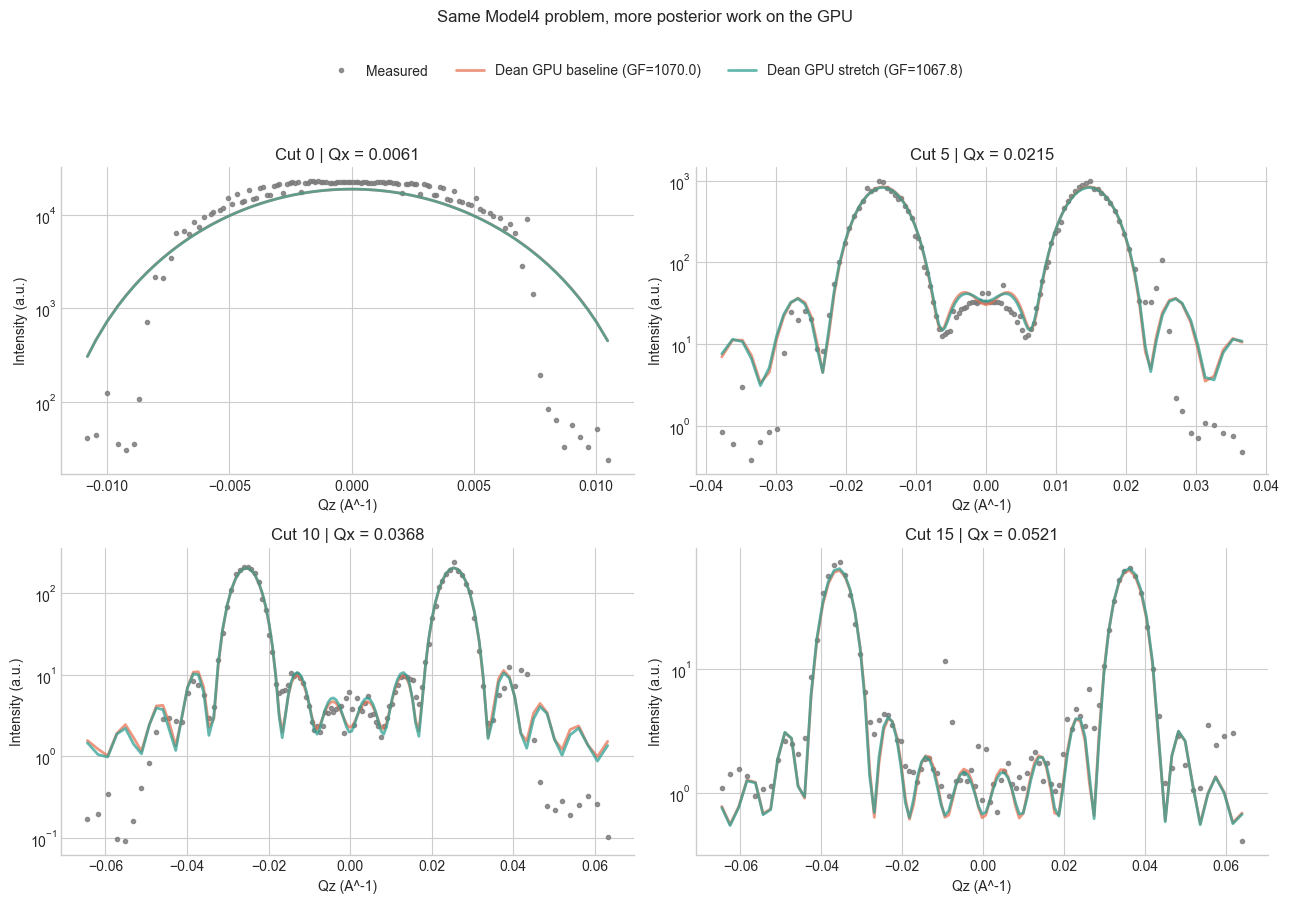

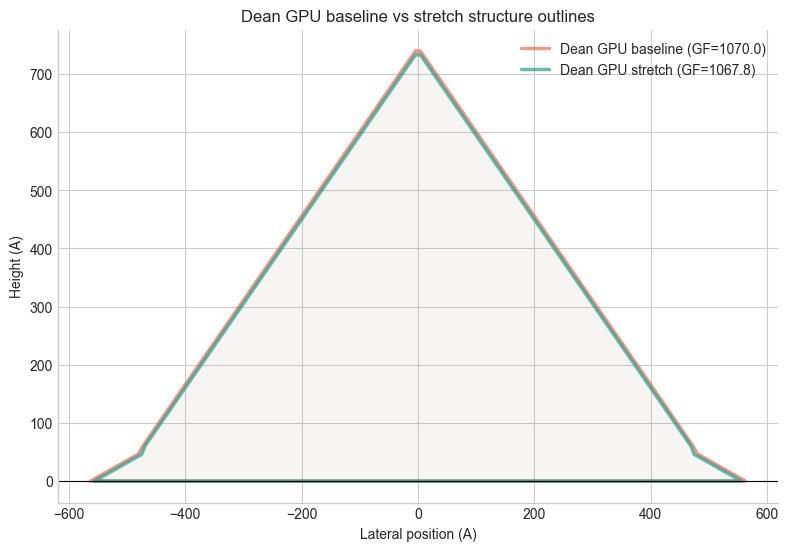

In [9]:
plot_fit_overlay(
    [gpu_model, gpu_stretch_model],
    ["Dean GPU baseline", "Dean GPU stretch"],
    [PALETTE["gpu"], PALETTE["stretch"]],
    cuts=SELECTED_CUTS,
    title="Same Model4 problem, more posterior work on the GPU",
)

plot_structure_overlay(
    [gpu_model, gpu_stretch_model],
    ["Dean GPU baseline", "Dean GPU stretch"],
    [PALETTE["gpu"], PALETTE["stretch"]],
    title="Dean GPU baseline vs stretch structure outlines",
)


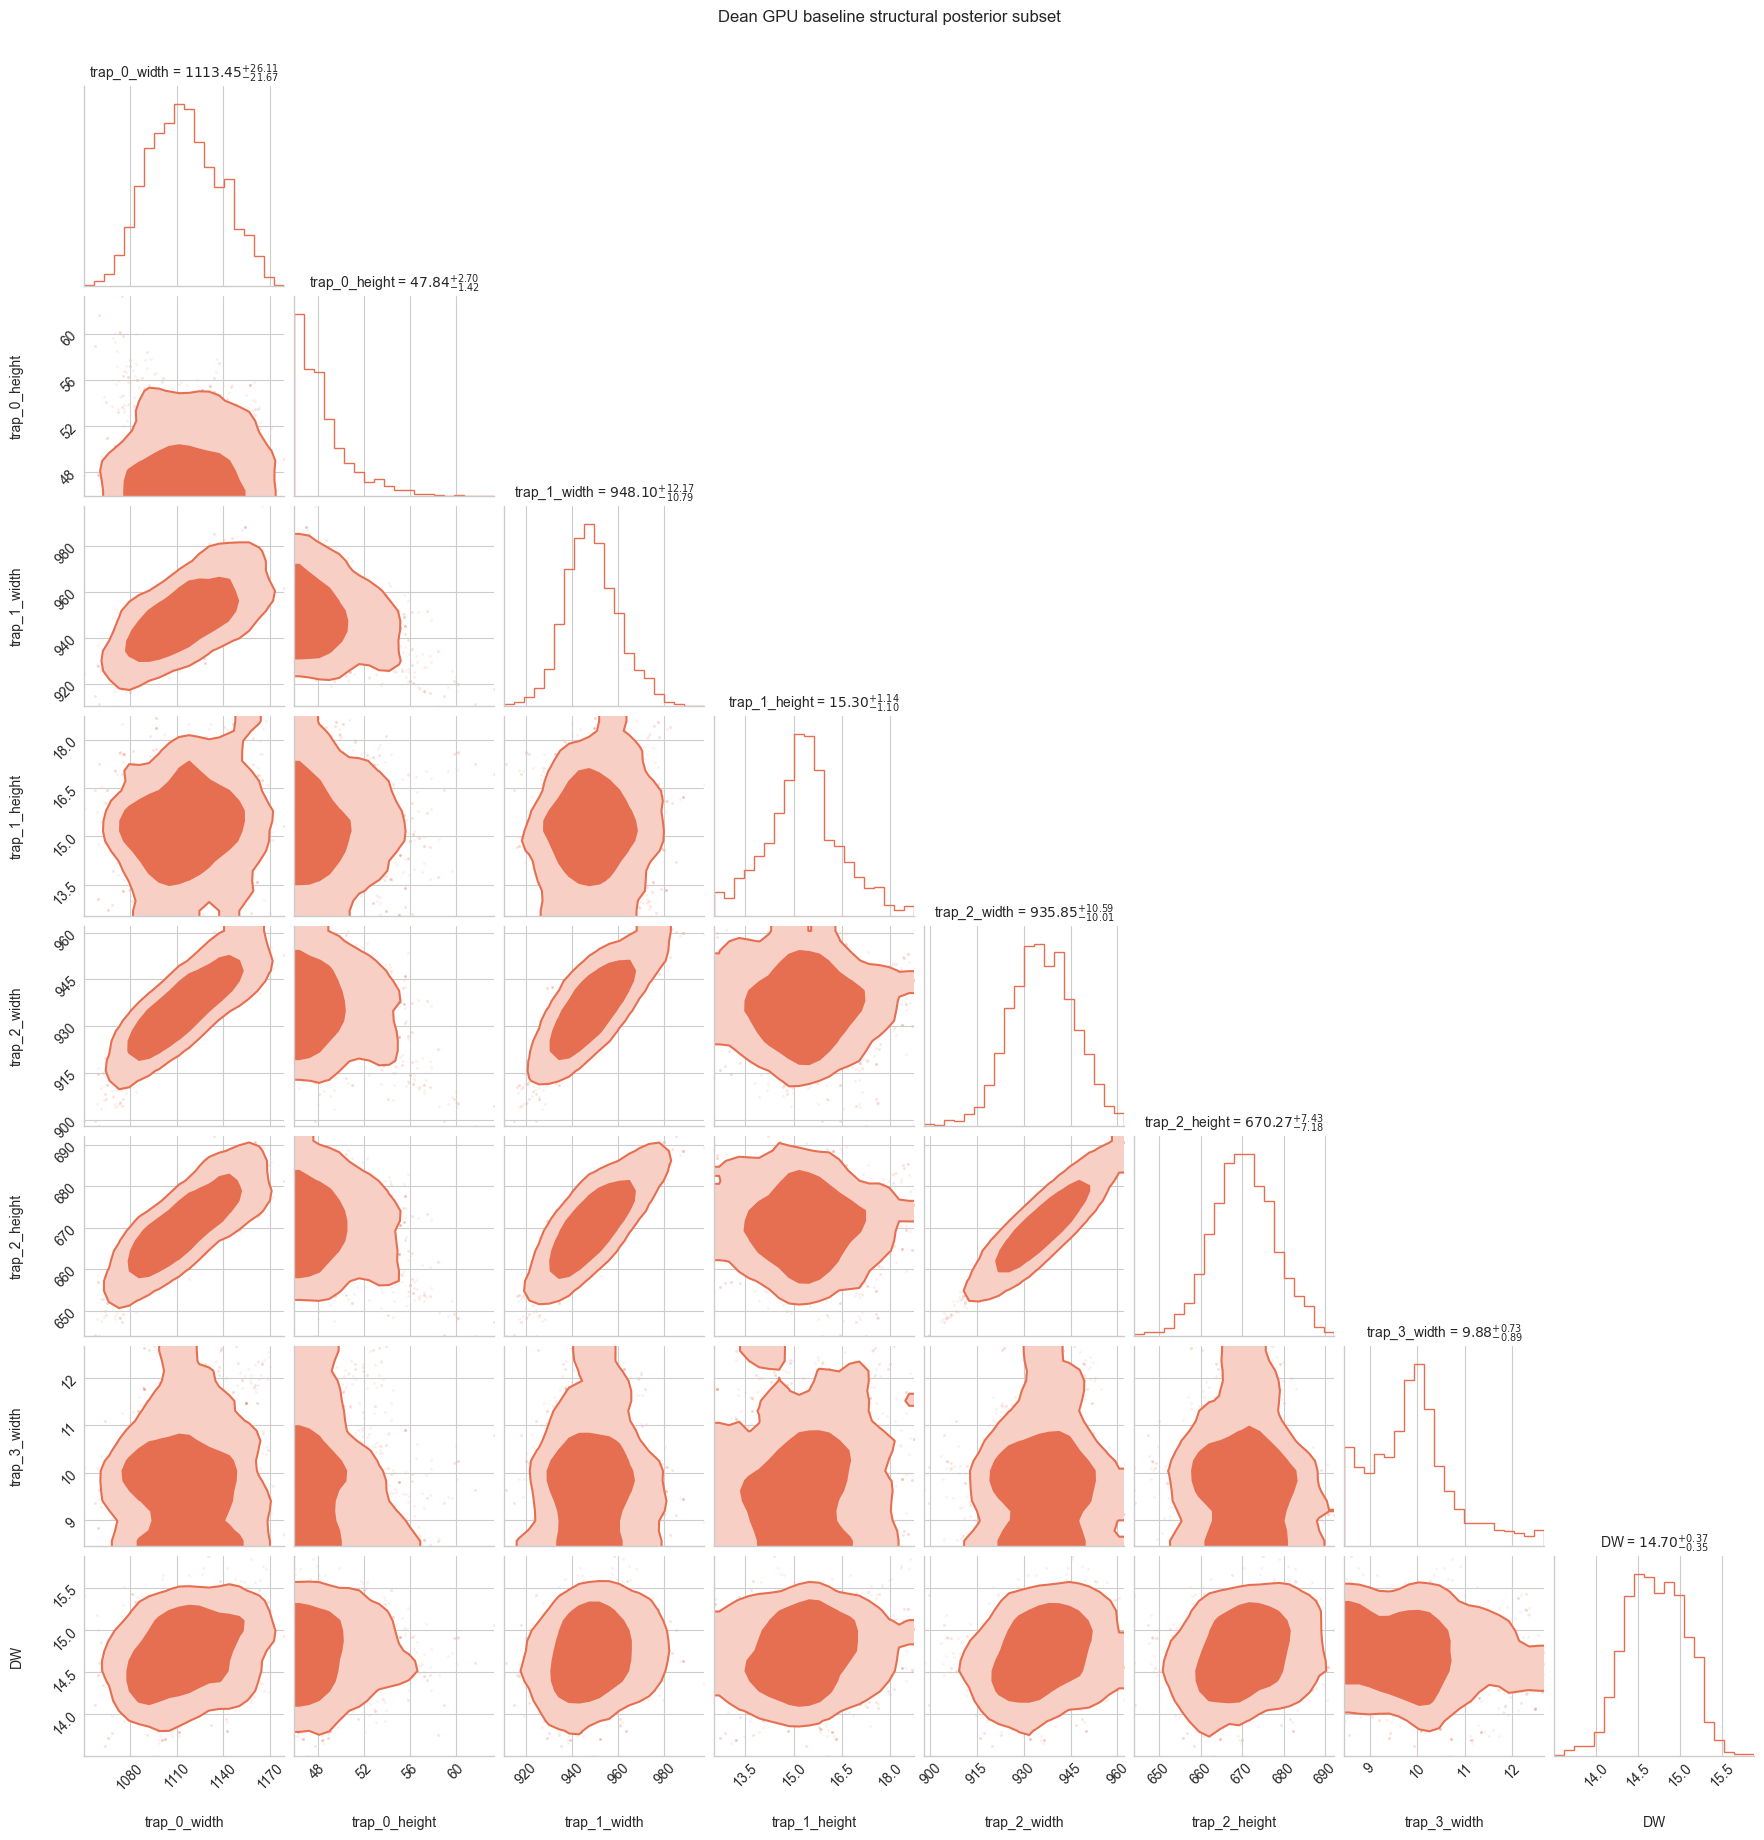

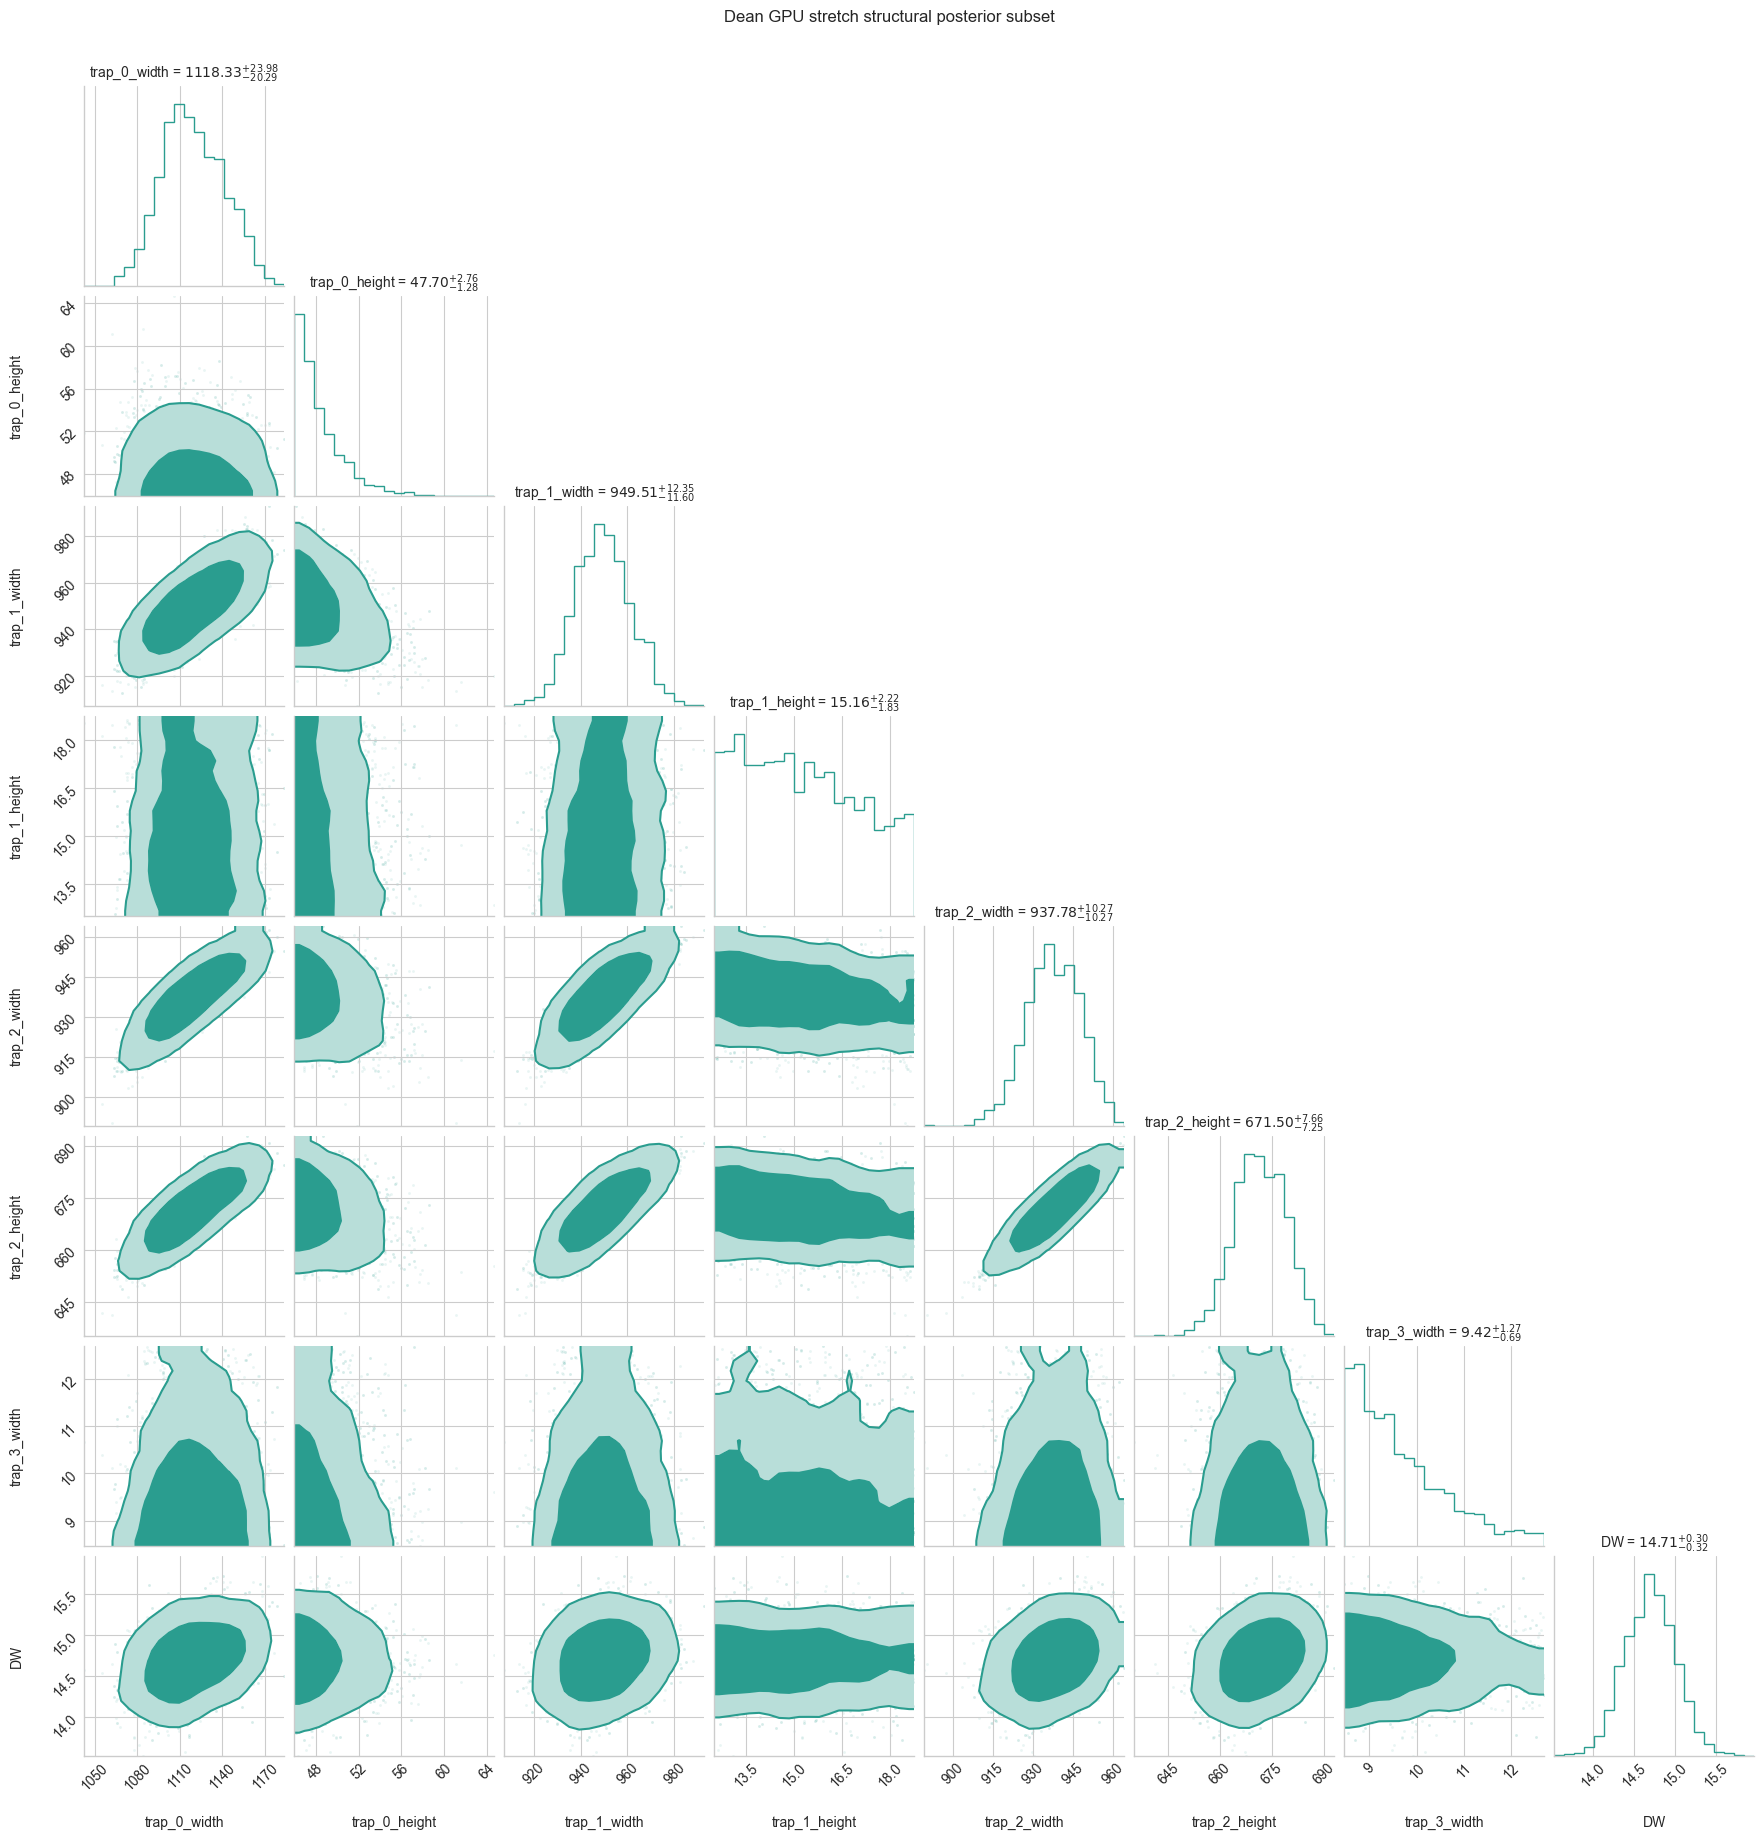

In [10]:
plot_corner_subset(
    gpu_mcmc_result,
    gpu_corner_param_names,
    title="Dean GPU baseline structural posterior subset",
    color=PALETTE["gpu"],
)

plot_corner_subset(
    gpu_stretch_mcmc_result,
    gpu_stretch_corner_param_names,
    title="Dean GPU stretch structural posterior subset",
    color=PALETTE["stretch"],
)


## Observations

- The literal `Model4` comparison only behaves like Notebook 3 when it is grown from a fitted shared `Model2` seed; the naive raw-default growth path lands in the wrong basin and never reaches the right fit regime.
- The native CPU-array incumbent now uses the same vectorized DE path exercised in the newer optimization harnesses, while the native MCMC samples a curated structural subset recentered on the DE optimum.
- On this machine, `GPU_DE popsize=128` is the useful aggressive baseline for literal `Model4`; pushing that DE population higher increases wall time without improving the final fit.
- Reinvesting the GPU savings into a much larger posterior run produces the same structural fit story with dramatically more post-burn samples and visibly tighter structural posteriors.
